# **Import Packages**

In [73]:
import numpy as np
from matplotlib import pyplot as plt
import seaborn as sns
# import pandas_profiling
# !pip install pandas==0.23.4
%matplotlib inline

# **Explore the datasets names in Seaborn**

In [74]:
import seaborn as sns
sns.get_dataset_names()


['anagrams',
 'anscombe',
 'attention',
 'brain_networks',
 'car_crashes',
 'diamonds',
 'dots',
 'dowjones',
 'exercise',
 'flights',
 'fmri',
 'geyser',
 'glue',
 'healthexp',
 'iris',
 'mpg',
 'penguins',
 'planets',
 'seaice',
 'taxis',
 'tips',
 'titanic']

# **Load Titanic data and explore it**

In [75]:
titanic = sns.load_dataset('titanic')

In [76]:
# Print multiple statements in same line
from IPython.core.interactiveshell import InteractiveShell
InteractiveShell.ast_node_interactivity = "all"

In [66]:
titanic.shape
titanic.info()
titanic.head()

(891, 15)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 15 columns):
 #   Column       Non-Null Count  Dtype   
---  ------       --------------  -----   
 0   survived     891 non-null    int64   
 1   pclass       891 non-null    int64   
 2   sex          891 non-null    object  
 3   age          714 non-null    float64 
 4   sibsp        891 non-null    int64   
 5   parch        891 non-null    int64   
 6   fare         891 non-null    float64 
 7   embarked     889 non-null    object  
 8   class        891 non-null    category
 9   who          891 non-null    object  
 10  adult_male   891 non-null    bool    
 11  deck         203 non-null    category
 12  embark_town  889 non-null    object  
 13  alive        891 non-null    object  
 14  alone        891 non-null    bool    
dtypes: bool(2), category(2), float64(2), int64(4), object(5)
memory usage: 80.7+ KB


,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
0,0,3,male,22.0,1,0,7.2500,S,Third,man,True,NaN,Southampton,no,False
1,1,1,female,38.0,1,0,71.2833,C,First,woman,False,C,Cherbourg,yes,False
2,1,3,female,26.0,0,0,7.9250,S,Third,woman,False,NaN,Southampton,yes,True
3,1,1,female,35.0,1,0,53.1000,S,First,woman,False,C,Southampton,yes,False
4,0,3,male,35.0,0,0,8.0500,S,Third,man,True,NaN,Southampton,no,True


# **Pandas Profiling**

In [ ]:
# import pandas_profiling

In [ ]:
# eda_report = pandas_profiling.ProfileReport(titanic)
# eda_report

In [77]:
titanic.head()

,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
0,0,3,male,22.0,1,0,7.2500,S,Third,man,True,NaN,Southampton,no,False
1,1,1,female,38.0,1,0,71.2833,C,First,woman,False,C,Cherbourg,yes,False
2,1,3,female,26.0,0,0,7.9250,S,Third,woman,False,NaN,Southampton,yes,True
3,1,1,female,35.0,1,0,53.1000,S,First,woman,False,C,Southampton,yes,False
4,0,3,male,35.0,0,0,8.0500,S,Third,man,True,NaN,Southampton,no,True


# **Drop unnecessary columns**

In [88]:
titanic.columns

Index(['survived', 'pclass', 'sex', 'age', 'sibsp', 'parch', 'fare',
       'embarked'],
      dtype='object')

In [92]:
titanic.drop(columns = ['who', 'adult_male', 'embark_town', 'alone', 'alive', 'class','deck'], inplace = True)

KeyError: "['who', 'adult_male', 'embark_town', 'alone', 'alive', 'class', 'deck'] not found in axis"

In [8]:
titanic.head()

,survived,pclass,sex,age,sibsp,parch,fare,embarked
0,0,3,male,22.0,1,0,7.2500,S
1,1,1,female,38.0,1,0,71.2833,C
2,1,3,female,26.0,0,0,7.9250,S
3,1,1,female,35.0,1,0,53.1000,S
4,0,3,male,35.0,0,0,8.0500,S


# **Rename columns**

In [9]:
titanic = titanic.rename(columns = {"sex":"gender", "sibsp":'siblings', "parch":"parents_child"})
titanic.head()
titanic['embarked'].value_counts()

,survived,pclass,gender,age,siblings,parents_child,fare,embarked
0,0,3,male,22.0,1,0,7.2500,S
1,1,1,female,38.0,1,0,71.2833,C
2,1,3,female,26.0,0,0,7.9250,S
3,1,1,female,35.0,1,0,53.1000,S
4,0,3,male,35.0,0,0,8.0500,S


,count
embarked,
S,644
C,168
Q,77


# **Check for missing values**

In [10]:

titanic.isna().sum()

,0
survived,0
pclass,0
gender,0
age,177
siblings,0
parents_child,0
fare,0
embarked,2


In [93]:
titanic[titanic['embarked'].isna()]

,survived,pclass,sex,age,sibsp,parch,fare,embarked
61,1,1,female,38.0,0,0,80.0,NaN
829,1,1,female,62.0,0,0,80.0,NaN


In [95]:
titanic_age_missing = titanic[titanic['age'].isna()]
titanic_age_missing.shape
titanic_age_missing.sample(5)

(177, 8)

,survived,pclass,sex,age,sibsp,parch,fare,embarked
557,0,1,male,NaN,0,0,227.5250,C
388,0,3,male,NaN,0,0,7.7292,Q
214,0,3,male,NaN,1,0,7.7500,Q
235,0,3,female,NaN,0,0,7.5500,S
428,0,3,male,NaN,0,0,7.7500,Q


In [96]:
titanic[titanic['survived'].isna()]

,survived,pclass,sex,age,sibsp,parch,fare,embarked


In [14]:
titanic.head()

,survived,pclass,gender,age,siblings,parents_child,fare,embarked
0,0,3,male,22.0,1,0,7.2500,S
1,1,1,female,38.0,1,0,71.2833,C
2,1,3,female,26.0,0,0,7.9250,S
3,1,1,female,35.0,1,0,53.1000,S
4,0,3,male,35.0,0,0,8.0500,S


In [15]:
titanic.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 8 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   survived       891 non-null    int64  
 1   pclass         891 non-null    int64  
 2   gender         891 non-null    object 
 3   age            714 non-null    float64
 4   siblings       891 non-null    int64  
 5   parents_child  891 non-null    int64  
 6   fare           891 non-null    float64
 7   embarked       889 non-null    object 
dtypes: float64(2), int64(4), object(2)
memory usage: 55.8+ KB


# **Fill missing data with certain values**

In [16]:
titanic_treated = titanic.fillna({'age':35 , 'embarked' : 'S'})

In [17]:
titanic_treated.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 8 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   survived       891 non-null    int64  
 1   pclass         891 non-null    int64  
 2   gender         891 non-null    object 
 3   age            891 non-null    float64
 4   siblings       891 non-null    int64  
 5   parents_child  891 non-null    int64  
 6   fare           891 non-null    float64
 7   embarked       891 non-null    object 
dtypes: float64(2), int64(4), object(2)
memory usage: 55.8+ KB


In [18]:
titanic_treated.isna().sum()

,0
survived,0
pclass,0
gender,0
age,0
siblings,0
parents_child,0
fare,0
embarked,0


In [19]:
titanic_treated.iloc[[61,829],:]

,survived,pclass,gender,age,siblings,parents_child,fare,embarked
61,1,1,female,38.0,0,0,80.0,S
829,1,1,female,62.0,0,0,80.0,S


In [30]:
titanic[titanic['embarked'].isna()]

,survived,pclass,gender,age,siblings,parents_child,fare,embarked


In [34]:
titanic.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 8 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   survived       891 non-null    int64  
 1   pclass         891 non-null    int64  
 2   gender         891 non-null    object 
 3   age            714 non-null    float64
 4   siblings       891 non-null    int64  
 5   parents_child  891 non-null    int64  
 6   fare           891 non-null    float64
 7   embarked       891 non-null    object 
dtypes: float64(2), int64(4), object(2)
memory usage: 55.8+ KB


In [35]:
titanic['embarked'].value_counts()

,count
embarked,
S,646
C,168
Q,77


# **Replace missing values with mode for the categorical vars**

In [36]:
titanic['embarked'] = titanic['embarked'].fillna(titanic['embarked'].mode()[0])

In [37]:
titanic[titanic['embarked'].isna()]

,survived,pclass,gender,age,siblings,parents_child,fare,embarked


In [38]:
titanic_treated.iloc[[347,829],:]

,survived,pclass,gender,age,siblings,parents_child,fare,embarked
347,1,3,female,35.0,1,0,16.1,S
829,1,1,female,62.0,0,0,80.0,S


replace with median for numerical var

In [39]:
titanic['age'].median()

28.0

In [41]:
titanic['age'].mean()

np.float64(29.69911764705882)

In [61]:
# titanic = titanic.fillna(titanic.median())
titanic['age'] = titanic['age'].fillna(titanic['age'].median())

In [46]:
titanic.iloc[[347,633],:]

,survived,pclass,gender,age,siblings,parents_child,fare,embarked
347,1,3,female,28.0,1,0,16.100,S
633,0,1,male,28.0,0,0,7.225,S


In [45]:
titanic.describe()

,survived,pclass,age,siblings,parents_child,fare
count,891.000000,891.000000,891.000000,891.000000,891.000000,891.000000
mean,0.383838,2.308642,29.361582,0.523008,0.381594,31.361851
std,0.486592,0.836071,13.019697,1.102743,0.806057,42.435753
min,0.000000,1.000000,0.420000,0.000000,0.000000,7.225000
25%,0.000000,2.000000,22.000000,0.000000,0.000000,7.910400
50%,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,1.000000,3.000000,35.000000,1.000000,0.000000,31.000000
max,1.000000,3.000000,80.000000,8.000000,6.000000,249.006220


In [44]:
titanic.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 8 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   survived       891 non-null    int64  
 1   pclass         891 non-null    int64  
 2   gender         891 non-null    object 
 3   age            891 non-null    float64
 4   siblings       891 non-null    int64  
 5   parents_child  891 non-null    int64  
 6   fare           891 non-null    float64
 7   embarked       891 non-null    object 
dtypes: float64(2), int64(4), object(2)
memory usage: 55.8+ KB


In [47]:
titanic.quantile(np.arange(0,1.01,0.05))

TypeError: unsupported operand type(s) for -: 'str' and 'str'

<Axes: >

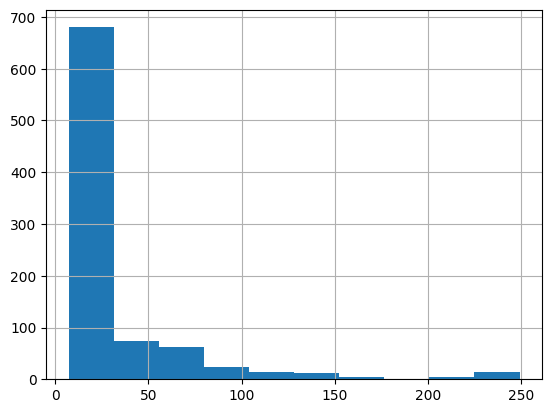

In [48]:
titanic['fare'].hist()

In [ ]:
titanic.quantile([0.0,1])

In [ ]:
titanic.quantile([0.01,0.99])

<ipython-input-36-522fbcda54b7>:1: FutureWarning: The default value of numeric_only in DataFrame.quantile is deprecated. In a future version, it will default to False. Select only valid columns or specify the value of numeric_only to silence this warning.
  titanic.quantile([0.01,0.99])


,survived,pclass,age,siblings,parents_child,fare
0.01,0.0,1.0,1.0,0.0,0.0,0.00000
0.99,1.0,3.0,65.0,5.0,4.0,249.00622


In [28]:
titanic.Fare.describe()

AttributeError: 'DataFrame' object has no attribute 'Fare'

In [ ]:
titanic.fare.hist()

In [29]:
titanic['fare'].quantile([0.00,1])

,fare
0.0,0.0000
1.0,512.3292


In [33]:
titanic.fare= np.clip(titanic.fare, titanic.fare.quantile(0.05), titanic.fare.quantile(0.99))

In [ ]:
titanic.fare.describe()

count    891.000000
mean      31.348347
std       42.366571
min        7.225000
25%        7.910400
50%       14.454200
75%       31.000000
max      247.669342
Name: fare, dtype: float64

# **Flooring and Capping for all columns in the dataset**

In [ ]:
iris_df = pd.read_csv('Iris.csv')
iris_df.head()

In [ ]:
iris_df.drop('Id', axis = 1, inplace= True)

In [ ]:
iris_df.describe()

In [ ]:
iris_df.quantile([0.01,0.99])

In [ ]:
iris_df.drop(['Species'], axis=1, inplace = True)

In [ ]:
for x in iris_df.columns:
    outlier = iris_df[x].quantile([0.01,0.99]).values
    iris_df[x] = np.clip(iris_df[x], outlier[0], outlier[1])

In [ ]:
iris_df.describe()

In [ ]:
iris_df['Species'].mode()

In [ ]:
iris_df['species'][iris_df['species'] == 'setosa'].count()
iris_df['species'][iris_df['species'] == 'versicolor'].count()
iris_df['species'][iris_df['species'] == 'virginica'].count()

In [ ]:
titanic[titanic['Embarked'].isnull()]

In [ ]:
titanic.iloc[[61,829],:]

In [ ]:
titanic[titanic['Embarked'].isnull()]

In [ ]:
titanic['Embarked'].isnull().sum()

In [ ]:
titanic.info()

In [ ]:
titanic = titanic.fillna(titanic.median())

In [ ]:
titanic.info()

In [ ]:
titanic.iloc[[5,17,19],:]

In [ ]:
titanic['Age'].describe()


In [ ]:
for x in titanic.columns:
    if titanic[x].dtype == "object":
        titanic[x]=pd.Categorical(titanic[x]).codes

titanic.head()

In [ ]:
x = titanic.drop(['survived'], axis = 1)
x.head()

In [ ]:
y = titanic['survived']
y.head()

In [ ]:

from sklearn import metrics
from sklearn import tree
import warnings
from sklearn.model_selection import train_test_split
warnings.filterwarnings('ignore')
%matplotlib inline
import graphviz

In [ ]:
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.25, random_state=42, stratify = y)

In [ ]:
y_train.groupby(y_train).size()

In [ ]:
from sklearn import tree
my_tree_one = tree.DecisionTreeClassifier(max_depth = 2)

In [ ]:
my_tree_one.fit(x_train, y_train)

In [ ]:
predicted = my_tree_one.predict(x_test)

In [ ]:
print(metrics.classification_report(y_test, predicted))

In [ ]:
x_test.columns

In [ ]:
np.round(my_tree_one.feature_importances_,2)

In [ ]:
# Visualize the decision tree graph
# conda install -c anaconda graphviz
# conda install -c conda-forge python-graphviz
import graphviz
with open('tree.dot','w') as dotfile:
    tree.export_graphviz(my_tree_one, out_file=dotfile, feature_names=x.columns, filled=True)
    dotfile.close()

# You may have to install graphviz package using
# conda install graphviz
# conda install python-graphviz

from graphviz import Source

with open('tree.dot','r') as f:
    text=f.read()
    plot=Source(text)
plot

In [ ]:
plot.render("dt1.png")

In [ ]:
plot.filename('dt1.png')

In [ ]:
plot.

In [ ]:
titanic.info()

In [ ]:
by_gender_class['age']

In [ ]:
titanic['age'].apply(impute_median)

In [ ]:
titanic.iloc[118,:]
titanic.iloc[121,:]

In [ ]:
titanic.info()

In [ ]:
import numpy as np

def detect_outliers(df,n,features):
    outlier_indices = []

    for col in features:
        Q1 = np.percentile(df[col], 25)
        Q3 = np.percentile(df[col],75)
        IQR = Q3 - Q1

        # outlier step
        outlier_step = 1.5 * IQR

        # Determine a list of indices of outliers for feature col
        outlier_list_col = df[(df[col] < Q1 - outlier_step) | (df[col] > Q3 + outlier_step )].index

        # append the found outlier indices for col to the list of outlier indices
        outlier_indices.extend(outlier_list_col)
    outlier_indices = collections.Counter(outlier_indices)
    multiple_outliers = list( k for k, v in outlier_indices.items() if v > n )

    return multiple_outliers

# detect outliers from Age, SibSp , Parch and Fare
Outliers_to_drop = detect_outliers(titanic,2,["age","sibsp","parch","fare"])


In [ ]:
Outliers_to_drop

In [ ]:
titanic = titanic.drop(Outliers_to_drop, axis = 0).reset_index(drop=True)
titanic.info()
titanic_data=titanic

In [ ]:
def convert_Sex(sex):
    if(sex=='female'):
        sex=1
    else:
        sex=0
    return sex

titanic['sex']=titanic['sex'].apply(convert_Sex)

In [ ]:
titanic.groupby('sex').size()

In [ ]:
class_dummies = pd.get_dummies(titanic['pclass'],prefix='class')
embark_dummies = pd.get_dummies(titanic['embarked'],prefix='port')

In [ ]:
embark_dummies.sample(100)

In [ ]:
titanic = pd.concat([titanic,class_dummies,embark_dummies],axis=1)
#titanic.drop(['Pclass','Embarked'],axis=1,inplace=True)
titanic.head(4)

In [ ]:
titanic.describe()['age']

In [ ]:
titanic.info()

In [ ]:
a=round(titanic.groupby('survived').mean(),2)
a

In [ ]:
a.port_S
a.sex
a.fare

In [ ]:
def persontype_func(age_Sex):
    age, sex = age_Sex
    if age < 16:
        return 'Child'
    elif sex == 1:
        return 'Woman'
    else:
        return 'Man'
titanic['PersonType'] = titanic[['age', 'sex']].apply(persontype_func, axis=1)

In [ ]:
df3 = titanic.loc[titanic['PersonType'] == 'Man'].head(2)
df3

In [ ]:
def persontype_func_num(age_Sex):
    age, sex = age_Sex
    if age < 16:
        m=2
    else:
        if sex == 1:
            m=1
        else:
            m=0
    return m
titanic['PersonType_num'] = titanic[['age', 'sex']].apply(persontype_func_num, axis=1)

In [ ]:
mx = sns.factorplot(x="pclass",hue="survived", data=titanic, kind="count", size=6)
mx.set(ylabel='Number of Passengers')
plt.title('Survival by PersonType');


In [ ]:
sns.distplot(titanic['age'], bins=15, kde=True)
plt.ylabel('Count')
plt.title('Agewise distribution of the passengers aboard the Titanic')
plt.show();

In [ ]:
ax = sns.factorplot(x="pclass", y="survived", hue="PersonType", data=titanic,
                    kind="bar",aspect=1.5, size=6)
ax.set(ylabel='Percent of Passengers')
plt.title('Survival by Class and Person Type');

In [ ]:
#titanic_input.drop(['Pclass','Embarked'],axis=1,inplace=True)
plt.figure(figsize=(15,10))
sns.heatmap(titanic[['survived','sex','age','sibsp','parch','PersonType_num', 'pclass', 'fare']].corr()
            ,cmap="RdYlGn",annot=True)
plt.show();

In [ ]:
from matplotlib import style
style.use('ggplot')
#plt.figure(figsize=(12,4))
sns.boxplot(x='age',data=titanic)

In [ ]:
sns.lmplot('age', 'fare', data=titanic, fit_reg=True,
           hue="PersonType")
plt.title('Scatterplot of passengers grouped by Fare and Age')
plt.show();

In [ ]:
sns.lmplot('age', 'fare', data=titanic, fit_reg=False, hue="pclass", col="embarked")
plt.subplots_adjust(top=0.9)
plt.suptitle('Scatterplot of passengers w.r.t Fare and Age for diff. ports', fontsize=16)
plt.show();
